![banner](../../../docs/figs/brand_identity/banner.png)

# Week 6: Fashion-MNIST Classification

## Lesson overview

Train a convolutional neural network to recognize Fashion-MNIST clothing images. The input is a 28×28 grayscale image; the output is a score for each of ten classes and a predicted class.

**By the end, you can:** read image tensors and labels; explain the roles of training, validation, and test data; and inspect loss curves and example predictions.

**Before you begin:** This uses a data subset included in the repository, so no data download is needed. Run cells in order. Training time depends on your device.

<p align="center"><img src="../figs/fashion_classification_workflow.svg" alt="Schematic grayscale clothing image passes through convolutional feature maps to ten class scores" width="100%"><br><em>Figure 1. Follow a clothing image through learned feature maps to scores and a predicted label.</em></p>

**Use the figure:** Locate the 28×28 input and ten-score output in the code. The drawn shirt and bars are schematic; use the notebook's actual image, loss curves, and held-out predictions to discuss mistakes.


## Why this example matters

Clothing classes provide a concrete image-classification task: the model must turn pixels into a label. The goal is to trace the data contract and evaluate errors, rather than read a single accuracy number in isolation.

**Inputs and requirements:** Local Fashion-MNIST files under `data/fashion/`, PyTorch, and matplotlib; training may take several minutes. Class scores are model outputs, not calibrated confidence by default.

**Route through the lesson:** Inspect local images and labels → convert to tensors → define the CNN → compare training and validation curves → inspect test mistakes.

**As you work:** Before each model or plot cell, predict one result. After it runs, describe one observation, identify its source, and name one limitation.


## Dataset and model contract

Fashion-MNIST contains 28×28 grayscale clothing images and one of ten labels. The CNN receives a normalized tensor shaped **(batch, 1, 28, 28)** and returns ten class scores per image. This notebook reads the Fashion-MNIST files already stored under `data/fashion/`; no dataset download is needed. Training is real and may take several minutes. Loss curves and example predictions are displayed inline.


In [1]:
import matplotlib.pyplot as plt
from ccai9012 import nn_utils, viz_utils

## Step 1: Load the local Fashion-MNIST subset

Load the images and labels included in the repository. Display a few examples and check that each image matches its label.

In [2]:
# Load the repository's Fashion-MNIST subset; no dataset download is needed.
import gzip
import struct
from types import SimpleNamespace
from PIL import Image
from ccai9012.paths import DATA_DIR

LABEL_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
class FashionIDX:
    """Read the repository's compressed Fashion-MNIST IDX files."""
    def __init__(self, image_file, label_file):
        with gzip.open(image_file, "rb") as f:
            _, self.count, self.rows, self.cols = struct.unpack(">IIII", f.read(16))
            self.images = f.read()
        with gzip.open(label_file, "rb") as f:
            _, label_count = struct.unpack(">II", f.read(8))
            self.labels = f.read()
        if self.count != label_count:
            raise ValueError("Fashion-MNIST image and label counts differ")
        self.features = {"label": SimpleNamespace(names=LABEL_NAMES)}
    def __len__(self):
        return self.count
    def __getitem__(self, idx):
        start = idx * self.rows * self.cols
        pixels = self.images[start:start + self.rows * self.cols]
        return {"image": Image.frombytes("L", (self.cols, self.rows), pixels), "label": self.labels[idx]}

FASHION_DIR = DATA_DIR / "fashion"
dataset = {
    "train": FashionIDX(FASHION_DIR / "train-images-idx3-ubyte.gz", FASHION_DIR / "train-labels-idx1-ubyte.gz"),
    "test": FashionIDX(FASHION_DIR / "t10k-images-idx3-ubyte.gz", FASHION_DIR / "t10k-labels-idx1-ubyte.gz"),
}


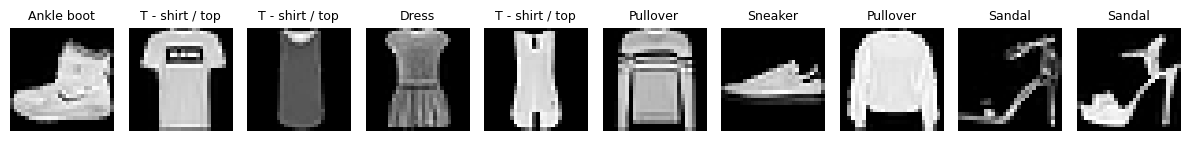

In [3]:
# Get the label names from the dataset
class_names = dataset['train'].features['label'].names

def show_samples(dataset, num_images=10):
    plt.figure(figsize=(12, 2))
    for i in range(num_images):
        image = dataset['train'][i]['image']
        label = dataset['train'][i]['label']
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(class_names[label], fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Show 10 sample images
show_samples(dataset)

## Step 2: Processing dataset for model training

Convert images to the numeric format expected by the model and split them into training, validation, and test sets. Validation and test examples do not update the model.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split

In [ ]:
# Wrap the local IDX reader as a PyTorch Dataset
class FashionDataset(Dataset):
    def __init__(self, image_dataset, transform=None):
        self.dataset = image_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]['image']
        label = self.dataset[idx]['label']
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
# Convert images to tensors and normalize them
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [7]:
# Prepare training, validation, and test sets

# Split training into train/validation sets
full_train_dataset = FashionDataset(dataset['train'], transform=transform)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Prepare test set
test_dataset = FashionDataset(dataset['test'], transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

## Step 3: Define a simple CNN model

The network takes image pixels and returns one score for each of ten clothing classes. The highest score is the model’s predicted class.

**Method guide:** A convolution applies the same small filter across the image, pooling reduces spatial detail, and the final layers combine responses into ten class scores. Use the feature-map lesson to inspect what intermediate filters respond to.


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (1, 28, 28) -> (32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                         # -> (32, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),# -> (64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                         # -> (64, 7, 7)
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)                          # 10 output classes
        )

    def forward(self, x):
        return self.model(x)

## Step 4: Model training

Watch whether training and validation loss decrease. A growing gap may mean the model is fitting the training examples without adapting as well to new ones.

In [9]:
# Set up training configuration
model = SimpleCNN()
num_epochs = 10

# CrossEntropyLoss applies softmax + loss in one step
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
# Train on training batches and use validation batches to check progress.
train_losses, val_losses = nn_utils.train_model(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    criterion, 
    num_epochs
)

Epoch [1/10] - Train Loss: 0.4546, Val Loss: 0.3220
Epoch [2/10] - Train Loss: 0.2904, Val Loss: 0.2803
Epoch [3/10] - Train Loss: 0.2413, Val Loss: 0.2757
Epoch [4/10] - Train Loss: 0.2101, Val Loss: 0.2310
Epoch [5/10] - Train Loss: 0.1816, Val Loss: 0.2256
Epoch [6/10] - Train Loss: 0.1573, Val Loss: 0.2185
Epoch [7/10] - Train Loss: 0.1354, Val Loss: 0.2378
Epoch [8/10] - Train Loss: 0.1136, Val Loss: 0.2414
Epoch [9/10] - Train Loss: 0.0981, Val Loss: 0.2605
Epoch [10/10] - Train Loss: 0.0822, Val Loss: 0.2743


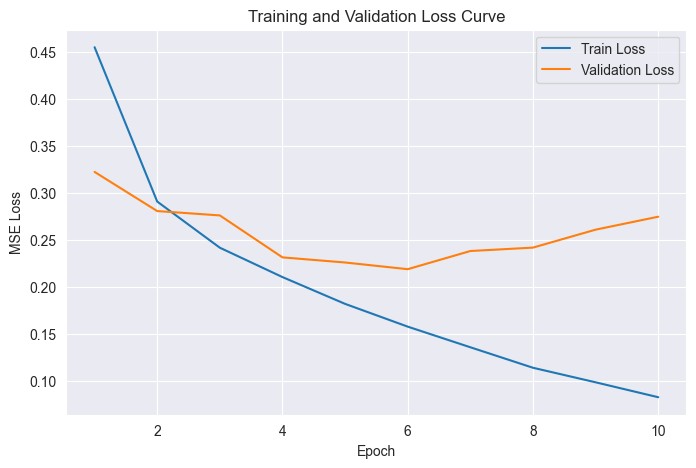

In [13]:
# Plot Training and Validation Loss
viz_utils.plot_loss_curve(train_losses, val_losses)

## Evaluate the model on the test set

Finally, check predictions on the held-out test examples. Compare each image, true label, and prediction to find clothing items the model confuses.

**Read the result:** Point to one correct and one incorrect example. Compare their true and predicted labels, then ask whether image ambiguity, limited training examples, or model capacity could help explain the error. One image cannot settle which explanation is right.


Accuracy: 91.08%

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86      1000
           1       1.00      0.98      0.99      1000
           2       0.87      0.87      0.87      1000
           3       0.89      0.90      0.89      1000
           4       0.85      0.86      0.86      1000
           5       0.97      0.99      0.98      1000
           6       0.73      0.79      0.76      1000
           7       0.97      0.94      0.96      1000
           8       0.99      0.98      0.98      1000
           9       0.96      0.98      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



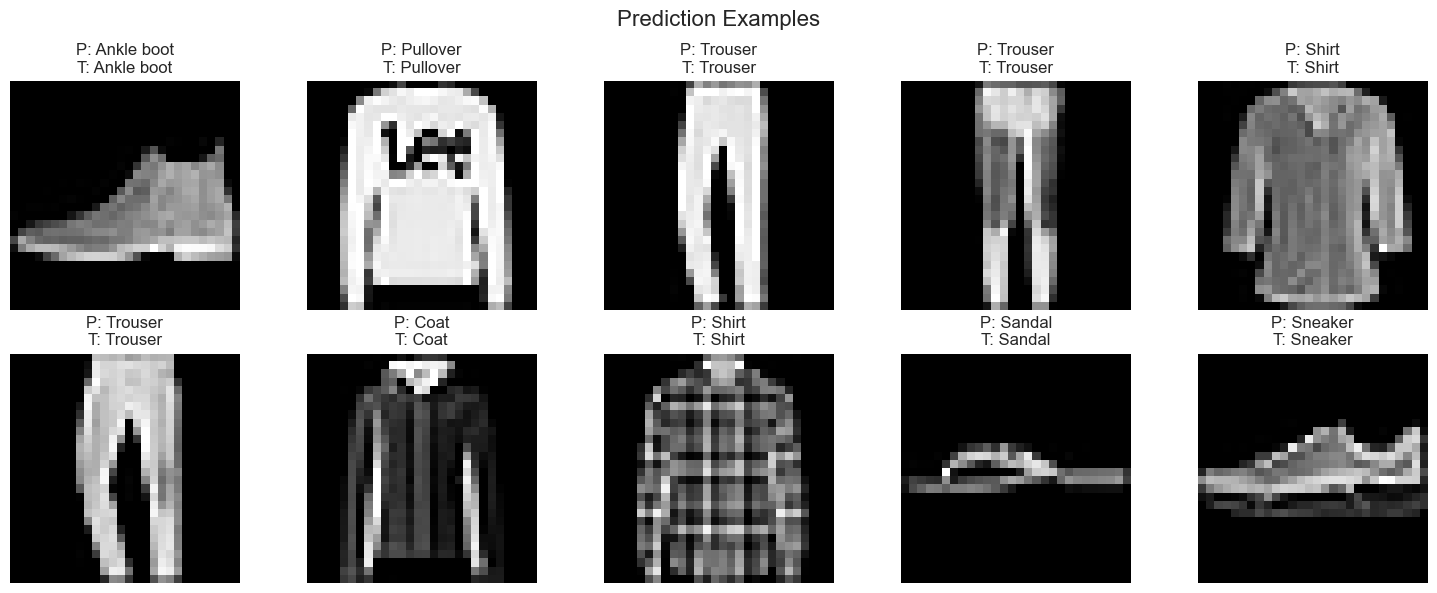

In [14]:
class_names = dataset['train'].features['label'].names

reuslts = nn_utils.evaluate_classification_model(
    model,
    test_loader,
    show_examples=True,
    class_names=class_names,
    num_examples=10,
    example_plot_title="Prediction Examples",
)

## What to take away

A CNN learns clothing classes from image pixels. **Try next:** Inspect misclassified examples. **Limit:** Accuracy on a small course dataset does not show how it will perform on real photos.